# Rheological data DTS / Storage modulus - Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-05

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import math
import re

## Import Data

In [4]:
database = 'Rheological Properties Data Libraries of scl-PHAs_V03'

## Create DataFrames for data points and properties

In [5]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(f'{database}.xlsx', sheet_name='Physchem_properties')

# Complex viscosity properties DataFrame
df_storage = pd.read_excel(f'{database}.xlsx', sheet_name='converted_MPa_Storage_modulus_G')

# Temperature DataFrame
df_temp = pd.read_excel(f'{database}.xlsx', sheet_name='Temperature')

# Experimental details DataFrame
df_exp = pd.read_excel(f'{database}.xlsx', sheet_name='Rheological_experimental_detail')

## Drop duplicates and remove multiple study+instance case (keep first)

In [6]:
print("Physicochemical Properties, rows before:", df_physicochem.shape[0])
df_physicochem = df_physicochem.drop_duplicates(subset=['Study_id', 'Instance'])
print("Physicochemical Properties, rows after:", df_physicochem.shape[0])

Physicochemical Properties, rows before: 336
Physicochemical Properties, rows after: 336


## Keep DTS data

In [7]:
exp_dict_dfs = (
    df_exp[df_exp['Test type'] == 'DTS']
    .groupby('Study_id')['Instance']
    .apply(list)
    .to_dict()
)

In [8]:
# Flatten exp_dict_dfs into a DataFrame of valid (Study_id, Instance) pairs
exp_pairs = [(sid, inst) for sid, instances in exp_dict_dfs.items() for inst in instances]
df_exp_pairs = pd.DataFrame(exp_pairs, columns=['Study_id', 'Instance'])

# Filter df_storage
df_storage_filtered = df_storage.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_temp
df_temp_filtered = df_temp.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_exp
df_exp_filtered = df_exp.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# FIlter df_physicochem
df_physic_filtered = df_physicochem.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Check all dfs have the same rows
df_storage_filtered.shape, df_temp_filtered.shape, df_exp_filtered.shape, df_physic_filtered.shape

((127, 45), (126, 29), (127, 22), (127, 22))

## Merge properties

In [9]:
df_merged_prop = pd.merge(df_physic_filtered, df_exp_filtered,  on=['Study_id', 'Instance'], how='left')
df_merged_prop.tail()

,Study_id,Instance,Monomer_A,Monomer_B,HB_ratio (mol%),HV_ratio (mol%),Mw_PHBV,Mn_PHBV,Density,Density_units,...,Texp,Texp_units,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz),Unnamed: 18,Unnamed: 19,Unnamed: 20_y,Row No._y
122,60,2,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,celsius,NaN,Pa,NaN,1.0,NaN,NaN,NaN,341
123,60,3,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,celsius,NaN,Pa,NaN,1.0,NaN,NaN,NaN,342
124,60,4,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,celsius,NaN,Pa,NaN,1.0,NaN,NaN,NaN,343
125,60,5,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,celsius,NaN,Pa,NaN,1.0,NaN,NaN,NaN,344
126,61,1,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,celsius,NaN,MPa,1.0,1.0,NaN,NaN,NaN,348


## Melt temperature values

In [10]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_temp_filtered.columns if c not in id_cols]

df_temp_filtered[value_cols] = df_temp_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
f_long = (
    df_temp_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="f_value")
    .dropna(subset=["f_value"])
)
f_long.head()

,Study_id,Instance,level_2,f_value
0,8,1,Unnamed: 2,-25.0
1,8,1,Unnamed: 3,-12.5
2,8,1,Unnamed: 4,0.0
3,8,1,Unnamed: 5,12.5
4,8,1,Unnamed: 6,25.0


## Melt storage modulus values

In [11]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_storage_filtered.columns if c not in id_cols]

df_storage_filtered[value_cols] = df_storage_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
v_long = (
    df_storage_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="v_value")
    .dropna(subset=["v_value"])
)
v_long.head()

,Study_id,Instance,level_2,v_value
0,8,1,Unnamed: 2,6874.068554
1,8,1,Unnamed: 3,6236.959762
2,8,1,Unnamed: 4,5275.707899
3,8,1,Unnamed: 5,4359.165425
4,8,1,Unnamed: 6,3643.815201


## Merge f and v values

In [12]:
fv_df = (
    f_long.merge(
        v_long,
        on=["Study_id", "Instance", "level_2"],
        how="inner"
    )
)
fv_df.head()

,Study_id,Instance,level_2,f_value,v_value
0,8,1,Unnamed: 2,-25.0,6874.068554
1,8,1,Unnamed: 3,-12.5,6236.959762
2,8,1,Unnamed: 4,0.0,5275.707899
3,8,1,Unnamed: 5,12.5,4359.165425
4,8,1,Unnamed: 6,25.0,3643.815201


In [13]:
# check size
f_long.shape, v_long.shape, fv_df.shape

((1511, 4), (1253, 4), (1205, 5))

## Merge properties with f,v values

In [14]:
df_merged_fnl = df_merged_prop.merge(
    fv_df[['Study_id', 'Instance', 'f_value', 'v_value']],
    on=['Study_id', 'Instance'],
    how='left'
)
df_merged_fnl = df_merged_fnl.dropna(subset=['f_value', 'v_value'])
df_merged_fnl.tail()

,Study_id,Instance,Monomer_A,Monomer_B,HB_ratio (mol%),HV_ratio (mol%),Mw_PHBV,Mn_PHBV,Density,Density_units,...,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz),Unnamed: 18,Unnamed: 19,Unnamed: 20_y,Row No._y,f_value,v_value
1223,61,1,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,MPa,1.0,1.0,NaN,NaN,NaN,348,160.0,80.835
1224,61,1,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,MPa,1.0,1.0,NaN,NaN,NaN,348,170.0,2.659
1225,61,1,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,MPa,1.0,1.0,NaN,NaN,NaN,348,180.0,1.953
1226,61,1,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,MPa,1.0,1.0,NaN,NaN,NaN,348,190.0,1.409
1227,61,1,3HB,3HV,100.0,0.0,NaN,NaN,NaN,NaN,...,NaN,MPa,1.0,1.0,NaN,NaN,NaN,348,200.0,1.128


In [15]:
df_merged_fnl.shape

(1205, 44)

## Rename columns

In [16]:
df_merged_fnl = df_merged_fnl.rename(columns={
    'f_value': 'temperature',
    'v_value': 'storage_modulus'
})

df_merged_fnl.columns

Index(['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'HB_ratio (mol%)',
       'HV_ratio (mol%)', 'Mw_PHBV', 'Mn_PHBV', 'Density', 'Density_units',
       'PDI', 'Additive_1', 'Additive1_type', 'Additive1_name',
       'Additive1_percentage (wt%)', 'Additive_2', 'Additive2_type',
       'Additive2_name', 'Additive2_percentage (wt%)',
       'final_formulation_PHA_percentage (wt%)', 'Unnamed: 20_x', 'Row No._x',
       'Test type', 'constant parameters', 'geometry', 'plate diameter',
       'gap size', 'morphology', 'diameter', 'thickness', 'size units',
       'Angular_frequency_units', 'Texp', 'Texp_units', 'Viscosity_units',
       'Modulus_units', 'Strain_fixed(%)', 'Frequency_experimental_fixed (Hz)',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20_y', 'Row No._y',
       'temperature', 'storage_modulus'],
      dtype='object')

## Drop duplicates

In [17]:
df_merged_fnl = df_merged_fnl.drop_duplicates()

## Replace N/A values with nan

In [18]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

## Fill in Mw, given PDI = Mw / Mn

In [19]:
mask_Mw = (
    df_merged_fnl['Mw_PHBV'].isna() &
    df_merged_fnl['Mn_PHBV'].notna() &
    df_merged_fnl['PDI'].notna()
)

df_merged_fnl.loc[mask_Mw, 'Mw_PHBV'] = (
    df_merged_fnl.loc[mask_Mw, 'PDI'] * df_merged_fnl.loc[mask_Mw, 'Mn_PHBV']
)

## Fix typos, excl. special characters

In [20]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val


In [21]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,monomer_a,monomer_b,hb_ratio_mol,hv_ratio_mol,mw_phbv,mn_phbv,density,density_units,...,viscosity_units,modulus_units,strain_fixed,frequency_experimental_fixed_hz,unnamed_18,unnamed_19,unnamed_20_y,row_no_y,temperature,storage_modulus
0,8,1,3HB,3HB,100.0,0.0,490000.0,NaN,1.25,g/cm3,...,Pa*s,MPa,NaN,1.0,NaN,NaN,NaN,29,-25.0,6874.068554
1,8,1,3HB,3HB,100.0,0.0,490000.0,NaN,1.25,g/cm3,...,Pa*s,MPa,NaN,1.0,NaN,NaN,NaN,29,-12.5,6236.959762
2,8,1,3HB,3HB,100.0,0.0,490000.0,NaN,1.25,g/cm3,...,Pa*s,MPa,NaN,1.0,NaN,NaN,NaN,29,0.0,5275.707899
3,8,1,3HB,3HB,100.0,0.0,490000.0,NaN,1.25,g/cm3,...,Pa*s,MPa,NaN,1.0,NaN,NaN,NaN,29,12.5,4359.165425
4,8,1,3HB,3HB,100.0,0.0,490000.0,NaN,1.25,g/cm3,...,Pa*s,MPa,NaN,1.0,NaN,NaN,NaN,29,25.0,3643.815201


In [22]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [23]:
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'density', 'density_units', 'pdi',
       'additive_1', 'additive1_type', 'additive1_name',
       'additive1_percentage_wt', 'additive_2', 'additive2_type',
       'additive2_name', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'unnamed_20_x', 'row_no_x',
       'test_type', 'constant_parameters', 'geometry', 'plate_diameter',
       'gap_size', 'morphology', 'diameter', 'thickness', 'size_units',
       'angular_frequency_units', 'texp', 'texp_units', 'viscosity_units',
       'modulus_units', 'strain_fixed', 'frequency_experimental_fixed_hz',
       'unnamed_18', 'unnamed_19', 'unnamed_20_y', 'row_no_y', 'temperature',
       'storage_modulus'],
      dtype='object')

In [24]:
df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0

df_clean['additive_1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive_2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive_1'] == 'no', 'additive1_type'] = 'no_additive'
df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'no_additive'

## Drop features with more than 50% missing values

In [25]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.50]
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'additive_1', 'additive1_type',
       'additive1_name', 'additive1_percentage_wt', 'additive_2',
       'additive2_type', 'additive2_percentage_wt',
       'final_formulation_pha_percentage_wt', 'row_no_x', 'test_type',
       'angular_frequency_units', 'texp_units', 'modulus_units',
       'frequency_experimental_fixed_hz', 'row_no_y', 'temperature',
       'storage_modulus'],
      dtype='object')

## Feature engineering

In [26]:
df_clean['additive1_type'].value_counts()

additive1_type
reinforcment_and_stiffening_modifiers     588
no_additive                               315
plasticizers_and_flexibility_enhancers    257
crosslinking_agent                         45
Name: count, dtype: int64

In [27]:
df_clean['additive2_type'].value_counts()

additive2_type
no_additive                               1015
plasticizers_and_flexibility_enhancers      99
reinforcment_and_stiffening_modifiers       91
Name: count, dtype: int64

## Feature selection

In [ ]:
df_clean.columns

In [28]:
# Select Features and Target
features = [
            'temperature',
            'study_id',
            'instance',
            'mw_phbv',
            'additive1_type',
            'additive1_percentage_wt',
            'additive2_type',
            'additive2_percentage_wt',
            'hb_ratio_mol',
            'hv_ratio_mol'
           ]

target = 'storage_modulus'
measure_unit = 'MPa'

In [29]:
# Create cleaned DataFrame
df_new = df_clean[features + [target]]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1205 entries, 0 to 1227
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature              1205 non-null   float64
 1   study_id                 1205 non-null   int64  
 2   instance                 1205 non-null   object 
 3   mw_phbv                  626 non-null    float64
 4   additive1_type           1205 non-null   object 
 5   additive1_percentage_wt  1205 non-null   float64
 6   additive2_type           1205 non-null   object 
 7   additive2_percentage_wt  1205 non-null   float64
 8   hb_ratio_mol             1145 non-null   float64
 9   hv_ratio_mol             1145 non-null   float64
 10  storage_modulus          1205 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 113.0+ KB


## Drop rows with nan value

In [30]:
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.head()

,temperature,study_id,instance,mw_phbv,additive1_type,additive1_percentage_wt,additive2_type,additive2_percentage_wt,hb_ratio_mol,hv_ratio_mol,storage_modulus
0,-25.0,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,6874.068554
1,-12.5,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,6236.959762
2,0.0,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,5275.707899
3,12.5,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,4359.165425
4,25.0,8,1,490000.0,plasticizers_and_flexibility_enhancers,10.0,no_additive,0.0,100.0,0.0,3643.815201


In [31]:
df_final['temperature'].describe()

count    626.000000
mean      36.512550
std       47.528020
min      -80.000000
25%        0.000000
50%       38.879000
75%       71.688889
max      137.500000
Name: temperature, dtype: float64

In [32]:
df_final['storage_modulus'].describe()

count    6.260000e+02
mean     1.154934e+07
std      8.215947e+07
min      1.007023e+02
25%      1.005710e+03
50%      2.196175e+03
75%      3.611383e+03
max      9.291484e+08
Name: storage_modulus, dtype: float64

In [33]:
df_final['mw_phbv'].describe()

count       626.000000
mean     406307.853035
std      119159.418459
min      150000.000000
25%      290000.000000
50%      450000.000000
75%      500000.000000
max      607000.000000
Name: mw_phbv, dtype: float64

In [34]:
df_final = df_final.copy()
df_final['log_storage_modulus'] = np.log10(df_final['storage_modulus'])
df_final['log_mw'] = np.log10(df_final['mw_phbv'])

In [35]:
df_final.columns

Index(['temperature', 'study_id', 'instance', 'mw_phbv', 'additive1_type',
       'additive1_percentage_wt', 'additive2_type', 'additive2_percentage_wt',
       'hb_ratio_mol', 'hv_ratio_mol', 'storage_modulus',
       'log_storage_modulus', 'log_mw'],
      dtype='object')

## Plot feature distribution

In [36]:
# Numerical columns
numerical_cols_lst = [
    'log_storage_modulus',
    'temperature',
    'log_mw',
    'additive1_percentage_wt',
    'additive2_percentage_wt',
    'hb_ratio_mol',
    'hv_ratio_mol'
]
# Categorical columns
categorical_cols_lst = [
    'additive1_type',
    'additive2_type',
]

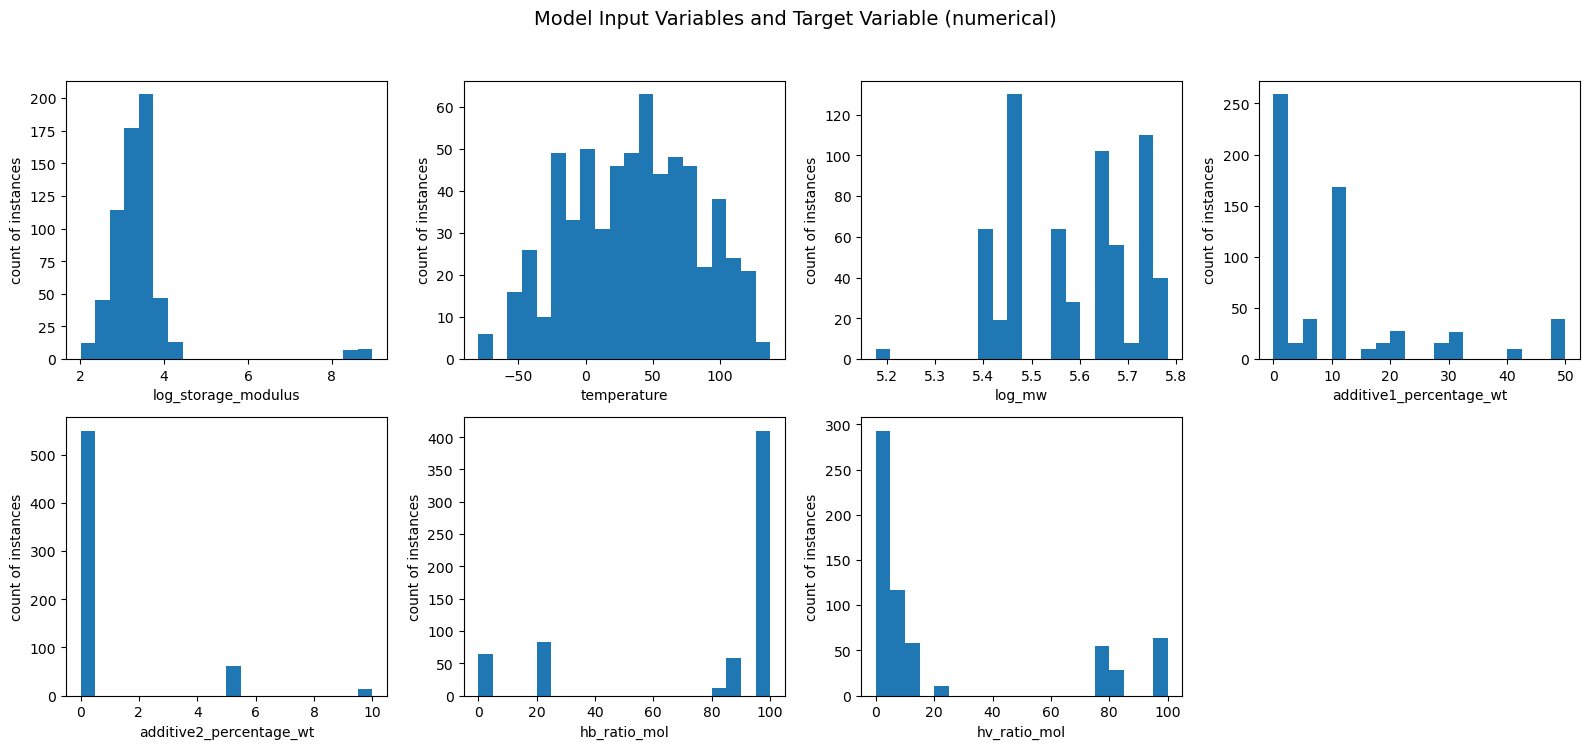

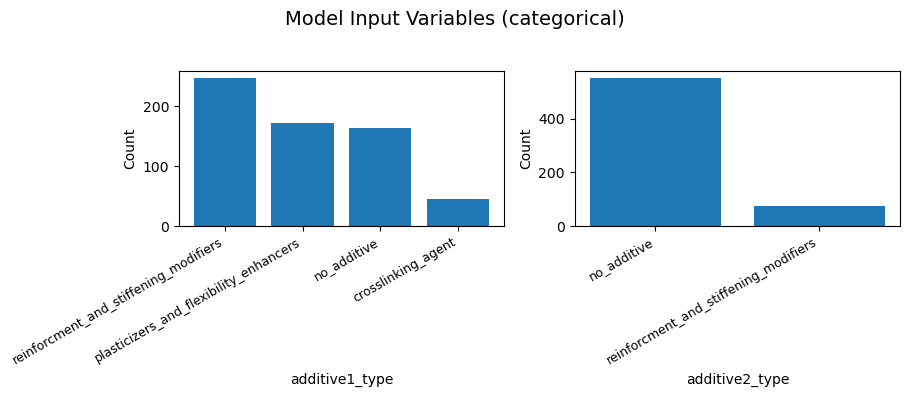

In [37]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("Count")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

plot_feature_distributions(
    df_final,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

## Remove features with only one value

In [38]:
constant_cols = df_final.columns[df_final.nunique(dropna=True) <= 1]
print("Removed columns:", list(constant_cols))
df_final = df_final.drop(columns=constant_cols)

Removed columns: []


In [39]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 626 entries, 0 to 1161
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature              626 non-null    float64
 1   study_id                 626 non-null    int64  
 2   instance                 626 non-null    object 
 3   mw_phbv                  626 non-null    float64
 4   additive1_type           626 non-null    object 
 5   additive1_percentage_wt  626 non-null    float64
 6   additive2_type           626 non-null    object 
 7   additive2_percentage_wt  626 non-null    float64
 8   hb_ratio_mol             626 non-null    float64
 9   hv_ratio_mol             626 non-null    float64
 10  storage_modulus          626 non-null    float64
 11  log_storage_modulus      626 non-null    float64
 12  log_mw                   626 non-null    float64
dtypes: float64(9), int64(1), object(3)
memory usage: 68.5+ KB


## Save

In [40]:
df_final.to_csv('rheological_DTS_data_storage_LM.csv', index=False)

## Profiling

In [41]:
import sweetviz as sv

exclude_cols = ['study_id', 'instance']
df_subset = df_final.drop(columns=exclude_cols)

report = sv.analyze(df_subset)
report.show_html("dataset_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
